# **Summer project:** Adaptive quantile boosted classification for imbalanced data
Lauryne Moyse

## Imports

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

from scipy.stats import norm
from scipy.special import expit
from scipy.interpolate import interp1d

from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, recall_score, precision_score, f1_score
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, auc, make_scorer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, TunedThresholdClassifierCV
from sklearn.datasets import make_classification
from sklearn.base import BaseEstimator
from sklearn.utils import resample
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import time
from functools import partial

In [ ]:
data_sheart = pd.read_csv("Data/heart.csv") #https://www.kaggle.com/datasets/yasserh/heart-disease-dataset
data_churn = pd.read_csv("Data/employee_churn_dataset.csv") #https://www.kaggle.com/datasets/ziya07/employee-churn-data?
data_heart = pd.read_csv("Data/heart_disease_health_indicators_BRFSS2015.csv") #https://www.kaggle.com/datasets/alexteboul/heart-disease-health-indicators-dataset
data_fraud = pd.read_csv("Data/transactions_sept_oct_2023.csv") #data science challenge

## Preliminary 

### Real data

In [ ]:
# Modify data_churn 
data_churn = data_churn[data_churn["Gender"]!='Other']
data_churn.drop("Employee ID", inplace=True, axis=1)

gender_map = {"Male": 0, "Female": 1}
education_map = {"High School": 0, "Bachelor's": 1, "Master's": 2, "PhD": 3}
marital_map = {"Single": 0, "Married": 1, "Divorced": 2}
jobrole_map = {"Analyst": 0, "Manager": 1, "Sales": 2, "Developer": 3}
department_map = {"HR": 0, "IT": 1, "Sales": 2, "Marketing": 3}
workmode_map = {"Remote": 0, "On-site": 1, "Hybrid": 2}
performance_map = {"Poor": 0, "Average": 1, "Good": 2, "Excellent": 3}

data_churn["Gender"] = data_churn["Gender"].map(gender_map)
data_churn["Education Level"] = data_churn["Education Level"].map(education_map)
data_churn["Marital Status"] = data_churn["Marital Status"].map(marital_map)
data_churn["Job Role"] = data_churn["Job Role"].map(jobrole_map)
data_churn["Department"] = data_churn["Department"].map(department_map)
data_churn["Work Location"] = data_churn["Work Location"].map(workmode_map)
data_churn["Work-Life Balance"] = data_churn["Work-Life Balance"].map(performance_map)

# Modify data_heart
df_pos = data_heart[data_heart.HeartDiseaseorAttack == 1].sample(n=500, random_state=0)
df_neg = data_heart[data_heart.HeartDiseaseorAttack == 0].sample(n=9500, random_state=0)
data_heart = pd.concat([df_pos, df_neg]).sample(frac=1, random_state=0)

In [10]:
def data_overview(data, target):

    print("Length of dataset: ", len(data))
    y = data[target]
    print("Positive class proportion (%): ", np.round(y.mean()*100, 1))
    X = data.drop(target, axis=1)

    # Correlation heatmap
    plt.figure(figsize=(9, 7))
    sns.heatmap(
        data.corr(), 
        cmap='coolwarm',
        fmt=".2f",
        annot=True,
        annot_kws={"size": 7},
    )
    plt.show()

    return np.array(X), np.array(y)

Length of dataset:  303
Positive class proportion (%):  54.5


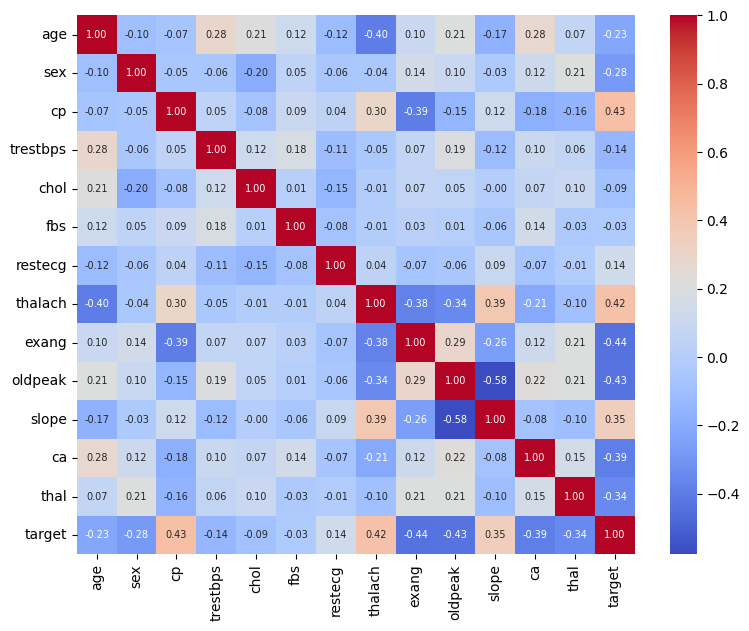

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1


In [300]:
X_sheart, y_sheart = data_overview(data_sheart, "target")
data_sheart.head(3)

Length of dataset:  9799
Positive class proportion (%):  20.4


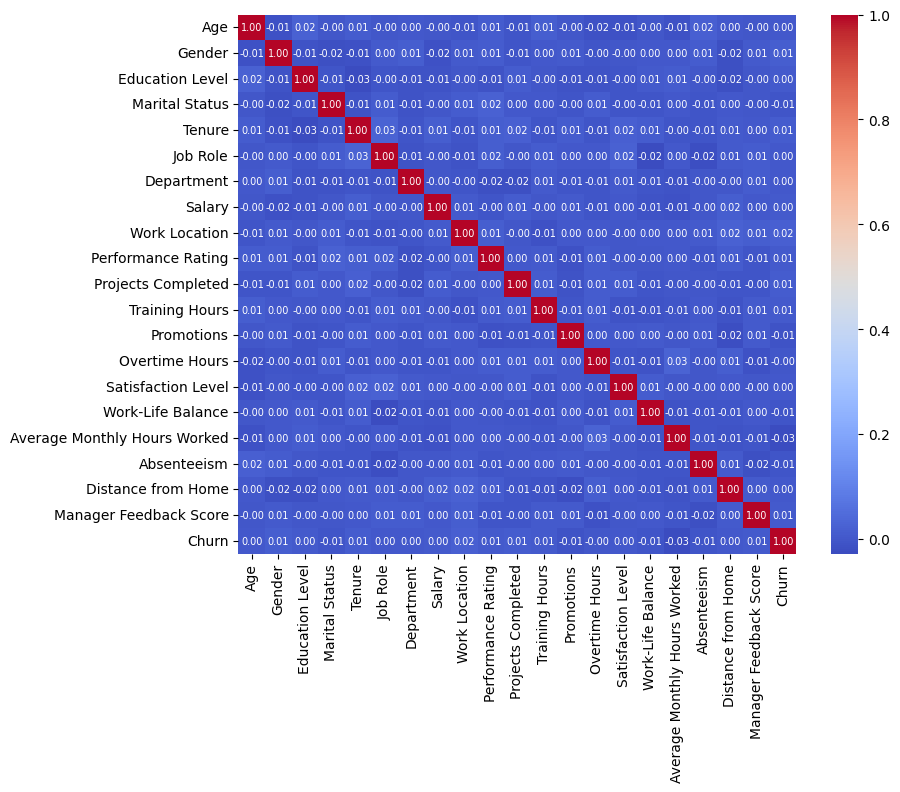

,Age,Gender,Education Level,Marital Status,Tenure,Job Role,Department,Salary,Work Location,Performance Rating,...,Training Hours,Promotions,Overtime Hours,Satisfaction Level,Work-Life Balance,Average Monthly Hours Worked,Absenteeism,Distance from Home,Manager Feedback Score,Churn
0,50,0,1,1,5,0,3,93422,0,5,...,35,0,16,0.03,0,155,14,15,7.9,0
1,36,0,1,1,4,1,2,44589,1,2,...,1,0,12,0.39,1,162,2,8,5.2,0
2,29,0,1,1,3,2,1,56768,2,1,...,41,0,2,0.62,0,243,6,21,6.3,0


In [301]:
X_churn, y_churn = data_overview(data_churn, "Churn")
data_churn.head(3)

Length of dataset:  10000
Positive class proportion (%):  5.0


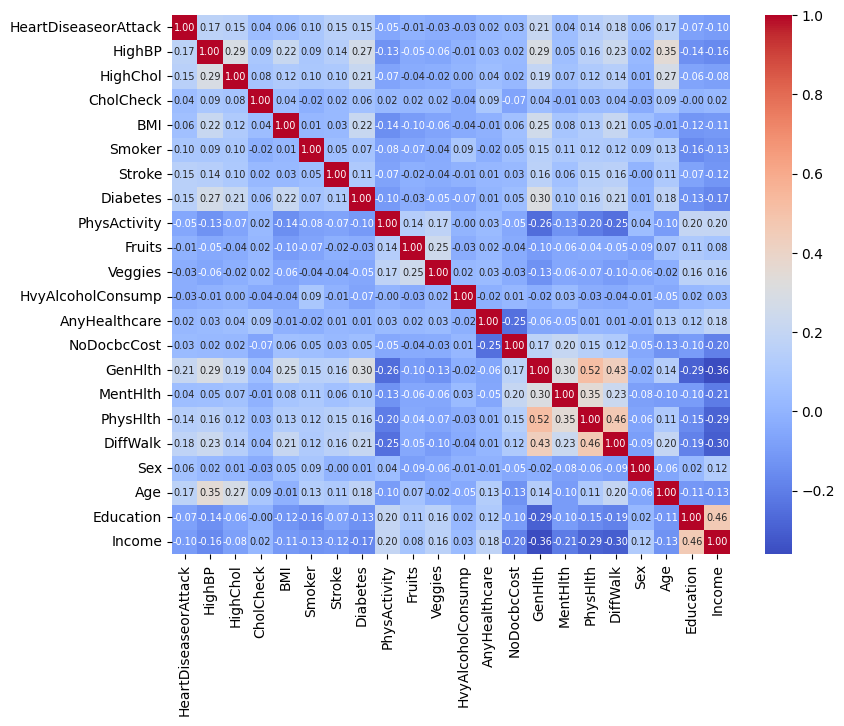

,HeartDiseaseorAttack,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,Diabetes,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
189149,0.0,1.0,1.0,1.0,35.0,1.0,0.0,2.0,0.0,1.0,...,1.0,0.0,4.0,0.0,3.0,1.0,1.0,11.0,6.0,8.0
141395,0.0,1.0,1.0,1.0,30.0,1.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,10.0,4.0,2.0
118998,0.0,0.0,0.0,1.0,27.0,1.0,0.0,0.0,1.0,0.0,...,1.0,0.0,1.0,0.0,2.0,0.0,1.0,4.0,6.0,8.0


In [302]:
X_heart, y_heart = data_overview(data_heart[:10000], "HeartDiseaseorAttack")
data_heart.head(3)

Length of dataset:  80000
Positive class proportion (%):  0.1


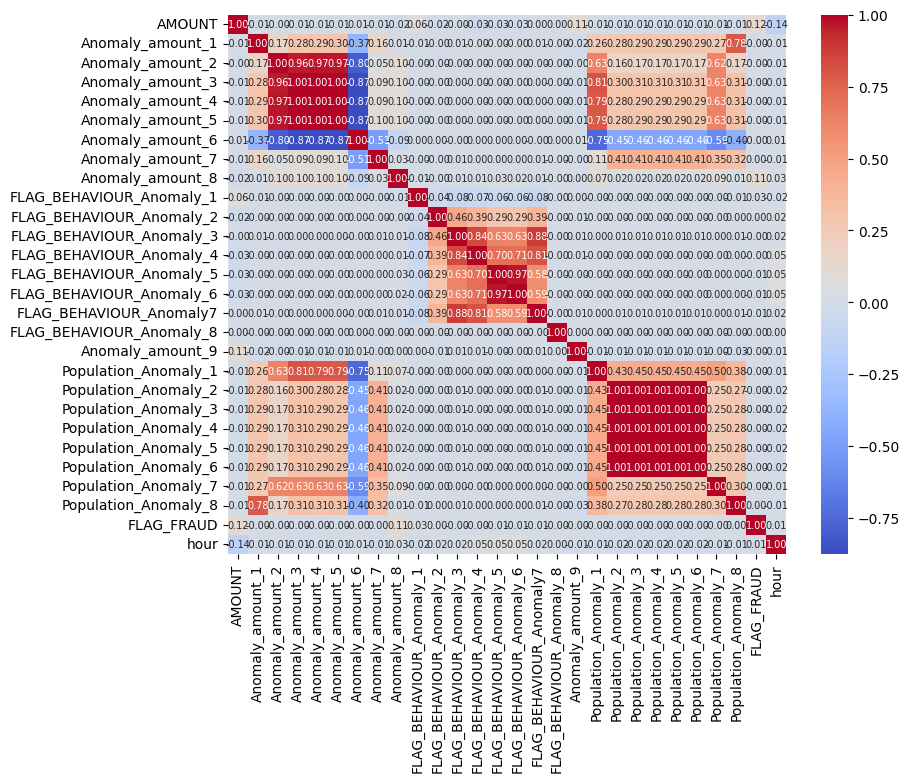

,AMOUNT,Anomaly_amount_1,Anomaly_amount_2,Anomaly_amount_3,Anomaly_amount_4,Anomaly_amount_5,Anomaly_amount_6,Anomaly_amount_7,Anomaly_amount_8,FLAG_BEHAVIOUR_Anomaly_1,...,Population_Anomaly_1,Population_Anomaly_2,Population_Anomaly_3,Population_Anomaly_4,Population_Anomaly_5,Population_Anomaly_6,Population_Anomaly_7,Population_Anomaly_8,FLAG_FRAUD,hour
0,-0.230107,-0.020722,-0.010212,-0.015482,-0.015938,-0.016001,-6.092665e-18,-0.015051,-0.06814,-0.209221,...,-0.015171,-0.020915,-0.021215,-0.021277,-0.020971,-0.020928,-0.015275,-0.023673,0,-2.715165
1,0.429478,-0.025458,-0.009663,-0.014449,-0.014798,-0.015009,-6.092665e-18,-0.019767,-0.06814,-0.209221,...,-0.016041,-0.033487,-0.033495,-0.033442,-0.033233,-0.033163,-0.010886,-0.021220,0,-2.513641
2,0.383191,-0.021317,-0.010213,-0.015217,-0.015810,-0.015288,-6.092665e-18,-0.016636,-0.06814,-0.209221,...,-0.014865,-0.033430,-0.033439,-0.033388,-0.033180,-0.033110,-0.015323,-0.026780,0,-2.433032


In [303]:
X_fraud, y_fraud = data_overview(data_fraud, "FLAG_FRAUD")
data_fraud.head(3)

In [15]:
scaler = MinMaxScaler()
X_sheart = scaler.fit_transform(X_sheart)
X_churn = scaler.fit_transform(X_churn)
X_heart = scaler.fit_transform(X_heart)
X_fraud = scaler.fit_transform(X_fraud)

### Synthetic data generation

In [ ]:
def generate_dataset(n_samples=10000, n_features=20, p=0.1, random_state=0):
    """
    Generates a binary classification dataset where y depends on X.
    The positive class has proportion p.
    """

    # Generate X
    rng = np.random.default_rng(random_state)  
    X = rng.standard_normal((n_samples, n_features))

    # Define a true underlying linear model
    weights = rng.standard_normal(n_features)
    logits = X @ weights

    # Shift threshold to control positive rate
    noisy = logits + rng.standard_normal(n_samples)
    threshold = np.percentile(noisy, 100 * (1 - p))
    y = (noisy >= threshold).astype(int)

    return X, y

In [ ]:
def cross_val_set(X, y, mode="train_test", test_size=0.2, val_size=None, n_splits=5, random_state=0):
    """
    Create train/test splits using either simple train_test or stratified k-fold.
    """

    if mode == "train_test":
        
        if val_size:
            X_temp, X_test, y_temp, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                random_state=random_state
            )
            val_relative = val_size / (1 - test_size)
            X_train, X_val, y_train, y_val = train_test_split(
                X_temp, y_temp,
                test_size=val_relative,
                stratify=y_temp,
                random_state=random_state
            )
            return X_train, X_val, X_test, y_train, y_val, y_test

        else:
            X_train, X_test, y_train, y_test = train_test_split(
                X, y,
                test_size=test_size,
                stratify=y,
                shuffle=True,
                random_state=0
            )
            return X_train, X_test, y_train, y_test

    elif mode == "kfold":
        skf = StratifiedKFold(
            n_splits=n_splits, 
            shuffle=True, 
            random_state=0)
        folds = [
            (X[train_idx], X[test_idx], y[train_idx], y[test_idx])
            for train_idx, test_idx in skf.split(X, y)
        ]
        return folds
    
    else:
        raise ValueError("mode should be 'train_test' or 'kfold'")

In [ ]:
# Test
X_01, y_01 = generate_dataset()
X_train_01, X_test_01, y_train_01, y_test_01 = cross_val_set(X_01, y_01)
print(np.mean(y_01))
print(np.mean(y_train_01))
print(np.mean(y_test_01))

0.1
0.1
0.1


In [ ]:
# Generate datasets
X_05, y_05 = generate_dataset(p=0.5)
X_train_05, X_test_05, y_train_05, y_test_05 = cross_val_set(X_05, y_05)
X_01, y_01 = generate_dataset(p=0.1)
X_train_01, X_test_01, y_train_01, y_test_01 = cross_val_set(X_01, y_01)
X_005, y_005 = generate_dataset(p=0.05)
X_train_005, X_test_005, y_train_005, y_test_005 = cross_val_set(X_005, y_005)
X_001, y_001 = generate_dataset(p=0.01)
X_train_001, X_test_001, y_train_001, y_test_001 = cross_val_set(X_001, y_001)
X_0001, y_0001 = generate_dataset(p=0.001)
X_train_0001, X_test_0001, y_train_0001, y_test_0001 = cross_val_set(X_0001, y_0001)

# Real datasets 
X_train_sheart, X_test_sheart, y_train_sheart, y_test_sheart = cross_val_set(X_sheart, y_sheart)
X_train_churn, X_test_churn, y_train_churn, y_test_churn = cross_val_set(X_churn, y_churn)
X_train_heart, X_test_heart, y_train_heart, y_test_heart = cross_val_set(X_heart, y_heart)
X_train_fraud, X_test_fraud, y_train_fraud, y_test_fraud = cross_val_set(X_fraud, y_fraud)

### SQBC class

In [133]:
class SQBC(BaseEstimator):

    def __init__(self, n_estimators=100, alpha=0.5, 
                 tau=0.5, eta=0.1, h=0.1, t=0, 
                 random_state=0, base_learner="tree"):
        if not 0 < tau < 1:
            raise ValueError("tau must be between 0 and 1")
        if base_learner not in ["tree", "OLS"]:
            raise ValueError("base_learner must be 'tree' or 'OLS'")
        self.n_estimators = n_estimators
        self.alpha = alpha
        self.tau = tau
        self.eta = eta
        self.h = h
        self.t = t
        self.random_state = random_state
        self.base_learner = base_learner
        self.models = []
        self.loss_history = []
    

    def compute_loss(self, X, y):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        Kf = norm.cdf(f/self.h)
        loss = self.tau * (y - Kf) + self.alpha * np.log1p(np.exp(-(y - Kf) / self.alpha))
        return np.mean(loss)
    

    def fit(self, X, y, verbose=False):
        f = np.zeros(len(y))
        self.models = []
        self.loss_history = []

        for m in range(self.n_estimators):

            Kf = norm.cdf(f/self.h)
            K_prime_f = norm.pdf(f/self.h) / self.h
            U = -K_prime_f * (1/(1 + np.exp((y - Kf)/self.alpha)) - self.tau)
            
            if self.base_learner=="tree":
                model = DecisionTreeRegressor(max_depth=1,random_state=self.random_state)
            elif self.base_learner=="OLS":
                model = LinearRegression()

            model.fit(X, U)
            self.models.append(model)
            f += self.eta * model.predict(X)

            # Keep loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            if (m % 10 == 0) and verbose:
                print(f"Iter {m}, loss = {loss:.4f}")

    
    # Predict quantile of Y*
    def predict_quantile(self, X):
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        return f
    

    # Predict Y by thresholding quantile of Y*
    def predict(self, X):
        if not self.models:
            raise ValueError("Model has not been fitted yet.")
        f = np.sum([self.eta * m.predict(X) for m in self.models], axis=0)
        return (f >= self.t).astype(int)
    
    
    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "alpha": self.alpha,
            "tau": self.tau,
            "eta": self.eta,
            "h": self.h,
            "t": self.t,
            "base_learner": self.base_learner
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self
    

    def plot_loss(self):
        plt.figure(figsize=(8, 5))
        plt.plot(self.loss_history, label="Loss")
        plt.xlabel("Iteration")
        plt.ylabel("Loss")
        plt.title("Training Loss per Iteration")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

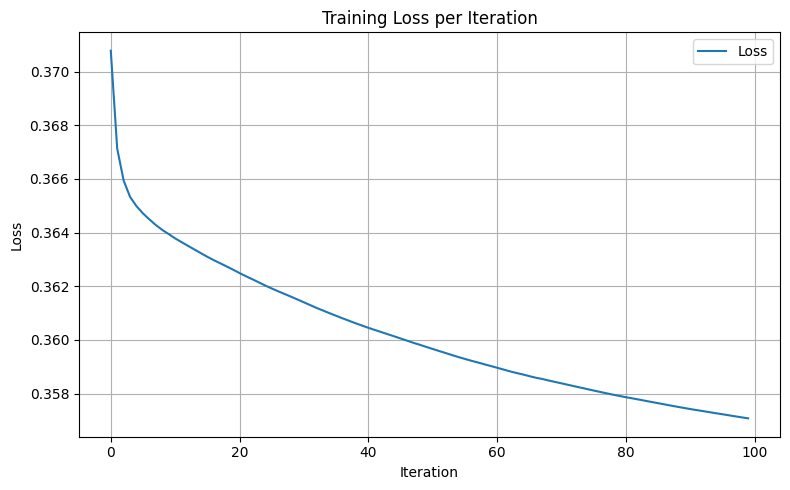

In [446]:
# Test
model = SQBC()
model.fit(X_train_01, y_train_01)
model.plot_loss()

### Classification evaluation

In [ ]:
# Define personnalized metrics 
 
def specificity_score(y_true, y_pred):
    """
    Computes specificity of classification.
    """

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    
    return specificity


def cost_score(y_true, y_pred, cost_10=10, cost_01=100, cost_11=10, cost_00=0, normalize=True):
    """
    Computes total cost of classification based on cost matrix.
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fp*cost_10 + fn*cost_01 + tp*cost_11 + tn*cost_00

    if normalize==True:
        FP = (y_true == 0).sum()
        FN = (y_true == 1).sum()
        max_cost = FP*cost_10 + FN*cost_01 
        total_cost = total_cost / max_cost if max_cost > 0 else 0.0
        
    return -total_cost

In [444]:
def evaluate(y_true, y_pred, y_scores, cost_10=10, cost_01=100, cost_11=10, cost_00=0, plot=True):
    """
    Returns and plots classification results.
    """  
    acc = accuracy_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred, zero_division=0) 
    prec = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    spec = specificity_score(y_true, y_pred)
    """
    w_acc = balanced_accuracy_score(y_true, y_pred) # harmonic mean of recall and specificty
    cost = -cost_score(y_true, y_pred, 
                        cost_10=cost_10, cost_01=cost_01, 
                        cost_11=cost_11, cost_00=cost_00
                    )
    """
    roc_auc = roc_auc_score(y_true, y_scores)
    pr_auc = average_precision_score(y_true, y_scores)

    metrics = {
            "pr_auc": round(pr_auc, 2),
            "f1": round(f1, 2),
            "roc_auc": round(roc_auc, 2),
            "accuracy": round(acc, 2),
            #"balanced_accuracy": round(w_acc, 2),
            "recall": round(rec, 2),
            "precision": round(prec, 2),
            "specificity": round(spec, 2),
            #"cost": round(cost, 2)
        }
    
    if plot:
        # Confusion matrix
        cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
        disp.plot()
        plt.show()

        print(metrics)
    
    return metrics 

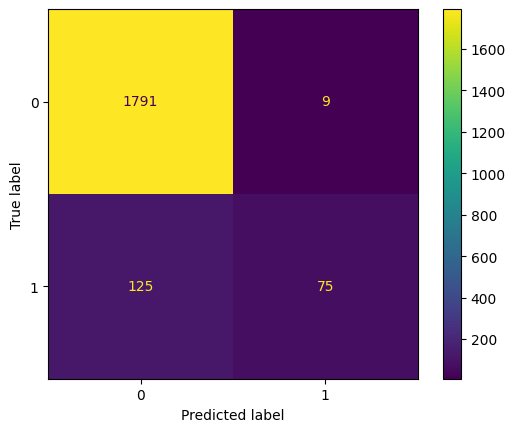

{'pr_auc': 0.81, 'f1': 0.53, 'roc_auc': 0.97, 'accuracy': 0.93, 'recall': 0.38, 'precision': 0.89, 'specificity': 1.0}


In [449]:
y_pred_01 = model.predict(X_test_01)
y_prob = model.predict_quantile(X_test_01)
metrics = evaluate(y_test_01, y_pred_01, y_prob)

### State-of-art models

In [450]:
def train_eval_sota_model(
        X_train, y_train, X_test, y_test, base_model, 
        opt_metric="pr_auc", opt_thresh=False, 
        thresholds = np.linspace(0, 1, 201)
    ): 
    """
    Train state-of-the-art model with an option for threshold optimization.
    """

    if opt_thresh == True: 

        if opt_metric == "precision":
            opt_metric = make_scorer(precision_score, zero_division=0)
        elif opt_metric == "pr_auc":
            opt_metric_scorer = make_scorer(average_precision_score, needs_proba=True)

        clf = TunedThresholdClassifierCV(
            estimator=base_model,
            scoring=opt_metric,
            thresholds=thresholds
        )
        clf.fit(X_train, y_train)
        y_pred = clf.predict(X_test)
        y_prob = clf.predict_proba(X_test)[:,1]
        metrics = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics["Threshold"] = round(clf.best_threshold_, 2)

    else: 
        base_model.fit(X_train, y_train)
        y_pred = base_model.predict(X_test)
        y_prob = base_model.predict_proba(X_test)[:,1]
        metrics = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics["Threshold"] = 0.5

    return metrics


In [ ]:
def pipeline_sota(X_train, y_train, X_test, y_test, 
                opt_metric="pr_auc",verbose=True, 
                opt_thresh=False,
                models={
                    'XGBoost': xgb.XGBClassifier(),
                    'LightGBM': lgb.LGBMClassifier(),
                    'CatBoost': CatBoostClassifier(verbose=0),
                    'Random_Forest': RandomForestClassifier(),
                    'Logistic_Regression': LogisticRegression(max_iter=1000)
                }):
    """
    Compares multiple classifier with a threshold optimization option for a single metric.
    Displays a summary table of all metrics.
    """
    list_metrics = []

    for name, base_model in models.items():
        
        if verbose:
            print(f"\nTraining {name}")

        metrics = train_eval_sota_model(
            X_train, y_train, X_test, y_test, base_model, 
            opt_metric=opt_metric, opt_thresh=opt_thresh
        )
        list_metrics.append(metrics)

    return list_metrics 

## *Optimal cost* 
**Unused section**

Specific part for optimizing the cost metric. In that case, we know that the optimal threshold is: 
$$p^* = \frac{C(1,0) - C(0,0)}{C(1,0)-C(0,0)+C(0,1)-C(1,1)} = 1 - \tau.$$
Which yields an optimal $\tau$:
$$\tau^* = \frac{C(0,1)-C(1,1)}{C(1,0)-C(0,0)+C(0,1)-C(1,1)}.$$

In [ ]:
def cost_vs_tau_plot_bootstrap(X, y, 
                     cost_10=10, cost_01=100, cost_11=10, cost_00=0,
                     tau_range=np.arange(0.01, 1, 0.05),
                     n_bootstrap=5, test_size=0.3,
                     n_estimators=100, alpha=0.5, 
                     eta=0.1, h=0.1, t=0, 
                     random_state=0, base_learner="tree"):
    """
    Average total cost for each tau value over bootstrap samples.
    """
    all_costs = []

    for b in range(n_bootstrap):
        print(f"Bootstrap step {b+1}")
        
        X_boot, y_boot = resample(X, y)
        X_train, X_test, y_train, y_test = train_test_split(
            X_boot, y_boot, test_size=test_size, stratify=y_boot
            )

        costs = []
        for tau in tau_range:
            model = SQBC(
                        n_estimators=n_estimators, alpha=alpha, 
                        tau=tau, eta=eta, h=h, t=t, 
                        random_state=random_state, base_learner=base_learner
                    )
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            cost = -cost_score(y_test, y_pred, cost_10, cost_01, cost_11, cost_00)
            costs.append(cost)
        all_costs.append(costs)

    all_costs = np.array(all_costs)
    avg_costs = np.mean(all_costs, axis=0)
    std_costs = np.std(all_costs, axis=0)
    print(tau_range)
    print(avg_costs - std_costs)
    print(avg_costs + std_costs)

    # Theoretical tau
    p_star = (cost_10 - cost_00) / (cost_10 - cost_00 + cost_01 - cost_11)
    tau_star = 1 - p_star

    # Plot
    plt.figure(figsize=(8, 5))
    plt.plot(tau_range, avg_costs, 'b-o', label='Avg Cost')
    if not np.allclose(avg_costs - std_costs, avg_costs + std_costs):
        plt.fill_between(
            tau_range,
            avg_costs - std_costs,
            avg_costs + std_costs,
            color='blue',
            alpha=0.2,
            label="±1 std"
            )
    plt.axvline(x=tau_star, color='red', linestyle='--', label=r'Theoretical $\tau^*$')
    plt.xlabel(r'Quantile level $\tau$')
    plt.ylabel('Total Cost')
    plt.title('Total Cost vs Threshold τ (with Bootstrap)')
    plt.grid(True)
    plt.legend()
    plt.tight_layout(rect=[0, 0.05, 1, 1]) 
    plt.show()


Bootstrap step 1
Bootstrap step 2
Bootstrap step 3
Bootstrap step 4
Bootstrap step 5


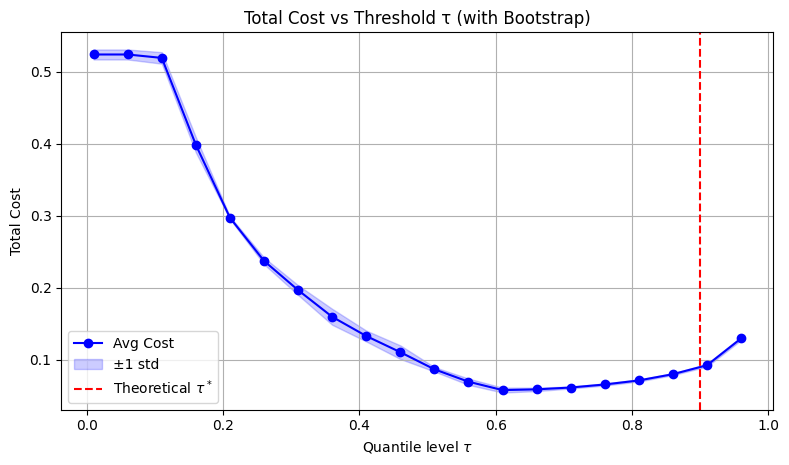

In [ ]:
cost_vs_tau_plot_bootstrap(X_01, y_01)

Divergence between theory and practice => to explain. The cost will therefore be optimized similarly to other metrics. 

## Effect of $\tau$ on metrics at different imbalance degrees

In [ ]:
def plot_metrics_vs_tau_for_imbalances(
        imbalances=[0.5, 0.1, 0.05, 0.01, 0.001], 
        tau_range=np.linspace(0.1, 1, 15, endpoint=False),
        nb_cols=3, 
    ):
    """
    For each imbalance level in 'imbalances', plot metric curves as a function of τ,
    and highlight the τ that optimize the metric.
    """
    metrics_names = [
        "f1",  "accuracy", 
        "recall", "precision", "specificity"
    ]
    n_imbalances = len(imbalances)

    # Prepare subplots
    total_plots = n_imbalances + 1 # one subplot for legend
    n_col = min(nb_cols, total_plots)
    n_row = total_plots//n_col + (total_plots%n_col > 0)

    fig, axes = plt.subplots(n_row, n_col, figsize=(15, 4*n_row), sharey=True)
    axes = axes.flatten()

    colors = plt.cm.get_cmap('tab10', len(metrics_names))

    for id, p in enumerate(imbalances):

        print('\nImbalance degree: ', p)

        X, y = generate_dataset(p=p)
        X_train, X_test, y_train, y_test = cross_val_set(X, y)

        metric_curves = {m: [] for m in metrics_names}

        for tau in tau_range:

            #print('Tau value: ', tau)

            # Fit model
            model = SQBC(tau=tau)
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            y_prob = model.predict_quantile(X_test)

            # Retrieve metrics 
            metrics = evaluate(y_test, y_pred, y_prob, plot=False)
            for m in metrics_names:
                metric_curves[m].append(metrics[m])

        # Plot metrics
        ax = axes[id]
        for i, m in enumerate(metrics_names):
            values = metric_curves[m]
            ax.plot(tau_range, values, linestyle='--', marker='o', markersize=4, color=colors(i), label=m)
            # Higlight best tau
            best_idx = np.argmin(values) if m=='cost' else np.argmax(values)
            best_tau = tau_range[best_idx]
            ax.plot(best_tau, values[best_idx], marker='^', markersize=10, color=colors(i))

        for tick in ax.get_yticklabels():
            tick.set_fontweight('bold')
        for tick in ax.get_xticklabels():
            tick.set_fontweight('bold')
        ax.set_title(f"P(Y=1) = {p}", fontsize=15, fontweight="bold")
        ax.set_xlabel(r"Quantile level $\tau$", fontsize=14, fontweight="bold")
        if id % n_col == 0:
            ax.set_ylabel("Metric value", fontsize=14, fontweight="bold")
        ax.grid(True)

    # Subplot for legend 
    legend_ax = axes[id+1]
    legend_ax.axis('off') 
    handles, labels = axes[0].get_legend_handles_labels()
    legend_ax.legend(handles, labels, loc='upper center', fontsize=12, ncol=2, frameon=False)

    # Delete empty plots
    for j in range(n_imbalances+1, n_row * n_col):
        fig.delaxes(axes[j])

    plt.suptitle("Metric evolution according to τ with best τ per metric (▲)", 
        fontsize=17, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.savefig("Figures/tau_metrics.pdf", dpi=600, format="pdf")
    plt.show()


Imbalance degree:  0.5

Imbalance degree:  0.1

Imbalance degree:  0.05

Imbalance degree:  0.01

Imbalance degree:  0.001


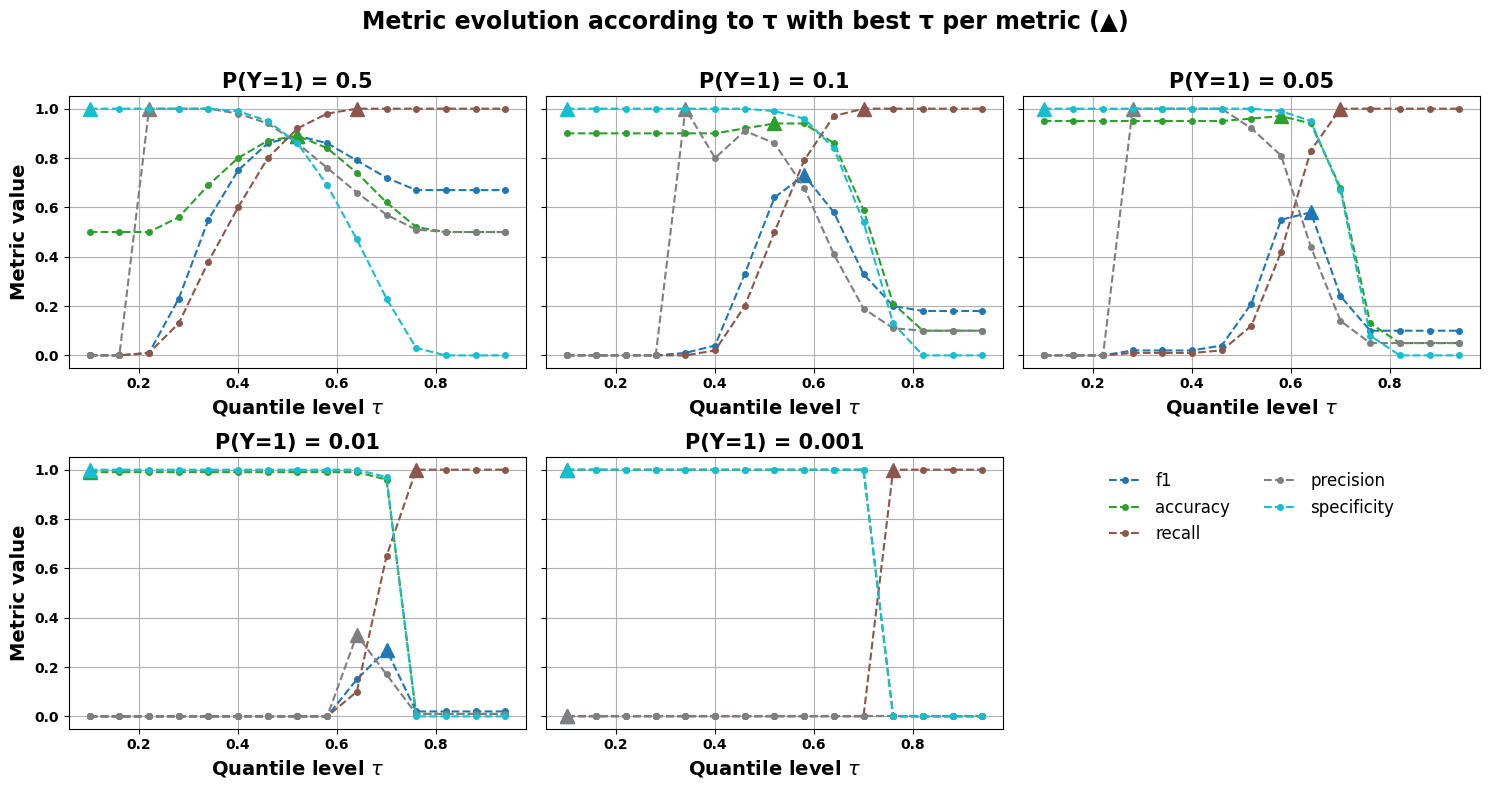

In [439]:
plot_metrics_vs_tau_for_imbalances()

## Standard SQBC

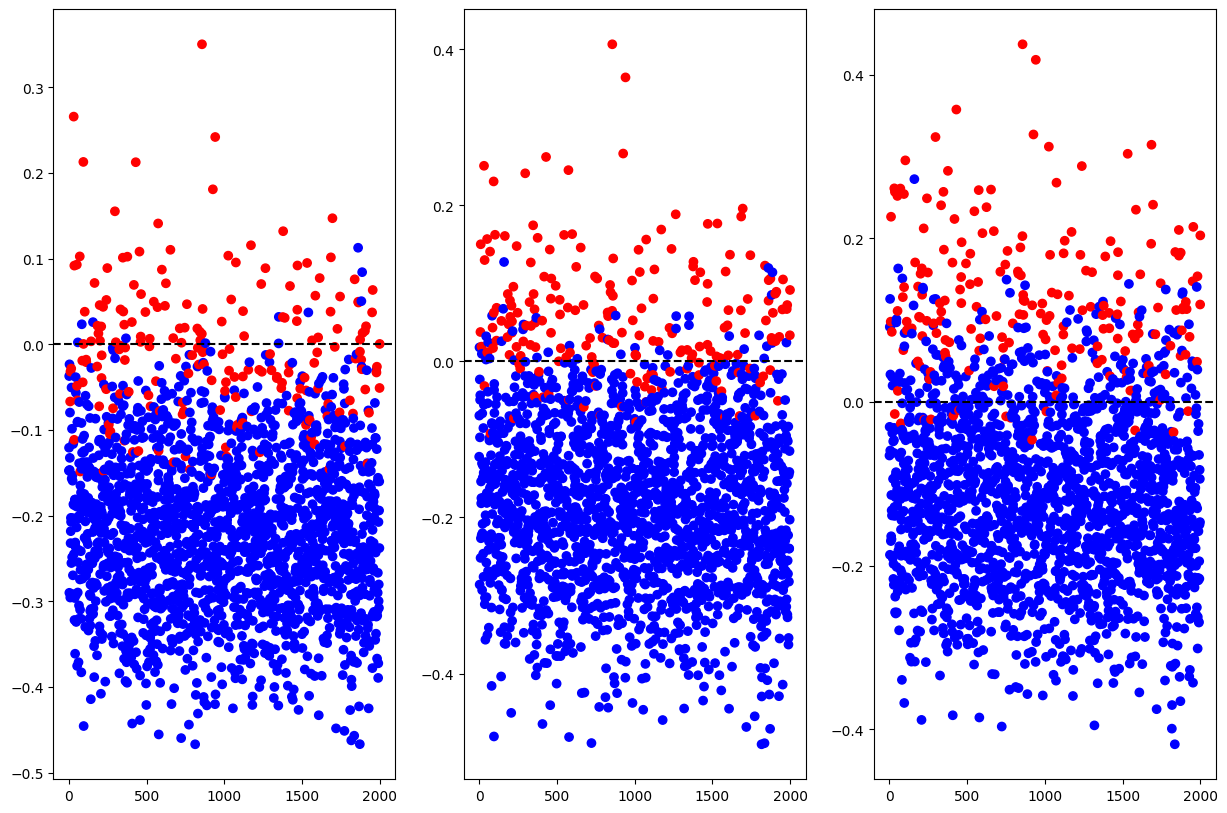

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 10), sharey=True)

for i, tau in enumerate([0.5, 0.65, 0.85]): 
 
    model_sqbc = NewSQBC(tau=tau)
    model_sqbc.fit(X_train_01, y_train_01)
    y_pred_sqbc = model_sqbc.predict_quantile(X_test_01)

    axs[i].scatter(range(len(y_pred_sqbc)), y_pred_sqbc, c=y_test_01, cmap='bwr')  
    axs[i].axhline(color='black', linestyle='--')

In [ ]:
def optimize_threshold_sqbc(model, X_train, y_train, X_test, 
                            y_test, opt_metric="pr_auc", 
                            n_splits=3, verbose=True, method=None):
    """
    SQBC threshold optimization via cross-validation.
    """
    folds = cross_val_set(X_train, y_train, mode="kfold", n_splits=n_splits)
    
    metrics = {
        "f1": f1_score, "pr_auc": average_precision_score, "accuracy": accuracy_score, 
        "roc_auc": roc_auc_score, "recall":recall_score, 
        "precision": precision_score, "specificity": specificity_score
    }
    metric_fn = metrics[opt_metric]

    thresholds = []
    scores = []
    
    for fold_id, (X_train_val, X_val, y_train_val, y_val) in enumerate(folds):

        if verbose==True:
            print(f"Fold {fold_id+1}/{n_splits}")

        if method==1:
            model.fit(X_train_val, y_train_val)
        elif method==2: 
            model.fit2(X_train_val, y_train_val)
        else:
            model.fit(X_train_val, y_train_val)

        y_prob = model.predict_quantile(X_val)
        
        # Search best threshold
        ts = np.concatenate((np.array([0]), np.linspace(min(y_prob), max(y_prob), 100)))
        fold_scores = [metric_fn(y_val, (y_prob >= t).astype(int)) for t in ts]
        
        best_idx = np.argmax(fold_scores)
        thresholds.append(ts[best_idx])
        scores.append(fold_scores[best_idx])
    
    best_threshold = np.median(thresholds)
    model.t = best_threshold
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_quantile(X_test)
    metrics = evaluate(y_test,y_pred.astype(int), y_prob, plot=False)

    return metrics, best_threshold

In [ ]:
def train_eval_sqbc(X_train, y_train, X_test, y_test, 
                    tau=0.5, alpha=0.5, h=0.1, t=0, 
                    base_learner="tree", opt_metric="pr_auc", 
                    opt_thresh=False, verbose=True):
    """
    Create and fit a SQBC algorithm, evaluate predictions and return classifications metrics. 
    """

    model = SQBC(tau=tau, alpha=alpha, h=h, t=t, base_learner=base_learner)

    if opt_thresh==True:
        metrics, threshold = optimize_threshold_sqbc(
            model, X_train, y_train, X_test, y_test, opt_metric=opt_metric, verbose=verbose
        )
        metrics["Threshold"] = round(threshold, 2)

    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_quantile(X_test)
        metrics = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics["Threshold"] = 0.0

    metrics["Level_tau"] = tau

    return metrics 

## Hyperparameter tuning: grid search of $\tau$

In [315]:
def grid_search_tau_interpolated(X_train, y_train, X_test, y_test,
                                tau_range=np.linspace(0.4, 0.99, 11),
                                cost_10=10, cost_01=100, cost_11=10, cost_00=0,
                                n_splits=3, resolution=200, interpolation=True,
                                n_estimators=100, alpha=0.5, 
                                eta=0.1, h=0.1, t=0, 
                                random_state=0, base_learner="tree",
                                model_type="SQBC",
                                verbose=True, opt_metric="pr_auc"):
    """
    Grid search over tau (with optional interpolation) to find the tau that optimizes opt_metric.
    """
    metrics_names = [
        "pr_auc", "f1", "roc_auc", "accuracy", 
        "recall", "precision", "specificity",
    ]
    if opt_metric not in metrics_names:
            raise ValueError("Invalid metric name")

    metric_curves = {m: np.zeros(len(tau_range)) for m in metrics_names}

    folds = cross_val_set(X_train, y_train, mode='kfold', n_splits=n_splits)
    for fold_id, (X_train_val, X_val, y_train_val, y_val) in enumerate(folds):
        
        if verbose==True: 
            print(f"Fold {fold_id + 1}/{n_splits}")

        for i, tau in enumerate(tau_range):
        
            # Create model
            if model_type=="SQBC":
                model = SQBC(
                            n_estimators=n_estimators, alpha=alpha, 
                            tau=tau, eta=eta, h=h, t=t, 
                            random_state=random_state, base_learner=base_learner
                        )
                # Fit and predict
                model.fit(X_train_val, y_train_val)
                y_pred = model.predict(X_val)
                y_prob = model.predict_quantile(X_val)

            elif model_type=="XGB":
                model = XGBSQBC(tau=tau, alpha=alpha, h=h)
                # Fit and predict
                model.fit(X_train_val, y_train_val)
                y_pred = model.predict(X_val)
                y_prob = model.predict_proba(X_val)[:,1]

            # Retrieve metrics
            metrics = evaluate(y_val, y_pred, y_prob, plot=False)
            for m in metric_curves:
                metric_curves[m][i] += metrics[m] / n_splits  # average over folds
        

    if interpolation==True: 
        interpolator = interp1d(tau_range, metric_curves[opt_metric])
        fine_taus = np.linspace(tau_range.min(), tau_range.max(), resolution)
        fine_metrics = interpolator(fine_taus)

        best_idx = np.argmin(fine_metrics) if opt_metric=='cost' else np.argmax(fine_metrics)
        best_tau = fine_taus[best_idx]

        
    else: 
        best_idx = np.argmin(metric_curves[opt_metric]) if opt_metric=='cost' else np.argmax(metric_curves[opt_metric])
        best_tau = tau_range[best_idx]
    

    # Model with best tau
    if model_type=="SQBC":
        model = SQBC(
                    n_estimators=n_estimators, alpha=alpha, 
                    tau=best_tau, eta=eta, h=h, t=t, 
                    random_state=random_state, base_learner=base_learner
                )
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_quantile(X_test)
        metrics_at_best = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics_at_best["Threshold"] = model.t


    elif model_type=="XGB":
        model = XGBSQBC(tau=best_tau, alpha=alpha, h=h)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:,1]
        metrics_at_best = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics_at_best["Threshold"] = 0.5
         
    else:
        raise ValueError("model should be 'SQBC' or 'XGB'")
    
    metrics_at_best["Level_tau"] = round(best_tau, 2)

    return metrics_at_best

## XGBoost with SQBC loss

In [ ]:
# Custom loss
def sqbc_like_loss(tau=0.5, alpha=0.5, h=0.1, eps=1e-6):
    """
    SQBC-inspired loss function for XGBoost.
    """

    def sqbc_obj(y_pred, dtrain):

        y_true = dtrain.get_label()
        f = y_pred  # raw score

        Kf = norm.cdf(f/h) 
        K_prime_f = norm.pdf(f/h) / h
        K_sec_f = -f/h**3 * norm.pdf(f/h)
        exp_term = np.exp((y_true - Kf)/alpha)

        grad = -K_prime_f * (tau - 1 / (1 + exp_term))
        hess = -K_sec_f * (tau - 1 / (1 + exp_term)) + K_prime_f**2/alpha * exp_term/(1+exp_term)**2 
        hess_clipped = np.maximum(hess, eps)
        
        return grad, hess_clipped

    return sqbc_obj

In [ ]:
class XGBSQBC(BaseEstimator):
    """
    XGBoost classifier with SQBC-like custom loss.
    """
    _estimator_type = "classifier"

    def __init__(self, tau=0.5, alpha=0.5, h=0.1,
                 max_depth=3, eta=0.1, n_estimators=100, 
                 random_state=0):
        self.tau = tau
        self.alpha = alpha
        self.h = h
        self.max_depth = max_depth
        self.eta = eta
        self.n_estimators = n_estimators
        self.random_state = random_state

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        
        dtrain = xgb.DMatrix(X, label=y)
        params = {
            "objective": 'binary:logistic',
            "max_depth": self.max_depth,
            "eta": self.eta,
            "verbosity": 0,
            "seed": self.random_state
        }
        self.bst_ = xgb.train(
            params, dtrain, num_boost_round=self.n_estimators,
            obj=sqbc_like_loss(self.tau, self.alpha, self.h)
        )
        return self

    def predict_proba(self, X):
        dtest = xgb.DMatrix(X)
        y_proba = self.bst_.predict(dtest)
        return np.column_stack((1 - y_proba, y_proba))

    def predict(self, X):
        proba = self.predict_proba(X)[:, 1]
        return (proba >= 0.5).astype(int)


In [ ]:
def train_eval_xgb_sqbc(X_train, y_train, 
                        X_test, y_test, 
                        tau=0.5, alpha=0.5, 
                        h=0.1, opt_metric="pr_auc", 
                        opt_thresh=False):
    """
    Create and fit a XGB-SQBC algorithm, evaluate predictions and return classifications metrics. 
    """
  
    model = XGBSQBC(tau=tau, alpha=alpha, h=h)

    metrics = train_eval_sota_model(
        X_train, y_train, X_test, y_test, model, 
        opt_metric=opt_metric, opt_thresh=opt_thresh
    ) 

    metrics["Level_tau"] = tau

    return metrics 

## Learning $\tau$ in SQBC

In [ ]:
class GradSQBC(SQBC):

    def __init__(self, n_estimators=100, alpha=0.5, 
                 theta=0, eta=0.1, h=0.1, t=0, 
                 random_state=0, base_learner="tree",
                 lr_theta = 0.1):
        if base_learner not in ["tree", "OLS"]:
            raise ValueError("base_learner must be 'tree' or 'OLS'")
        self.n_estimators = n_estimators
        self.alpha = alpha
        self.theta = theta
        self.tau = 1 / (1 + np.exp(-self.theta))
        self.eta = eta
        self.h = h
        self.t = t
        self.random_state = random_state
        self.base_learner = base_learner
        self.lr_theta = lr_theta


    # First fit method with naive gradient
    def fit(self, X, y, theta=0, verbose=False, base_learner="tree"):
        f = np.zeros(len(y))
        self.base_learner = base_learner
        self.models = []
        self.theta = theta
        self.tau = 1 / (1 + np.exp(-self.theta))
        self.loss_history = []

        for m in range(self.n_estimators):

            Kf = norm.cdf(f/self.h)
            K_prime_f = norm.pdf(f/self.h) / self.h
            U = -K_prime_f * (1/(1 + np.exp((y - Kf)/self.alpha)) - self.tau)
            
            if self.base_learner == "tree":
                model = DecisionTreeRegressor(max_depth=1, random_state=self.random_state)
            elif self.base_learner == "OLS":
                model = LinearRegression()

            model.fit(X, U)
            self.models.append(model)
            f += self.eta * model.predict(X)

            grad_theta = np.mean(y - Kf) * self.tau * (1 - self.tau)
            self.theta -= self.lr_theta * grad_theta
            self.tau = 1 / (1 + np.exp(-self.theta))

            # Keep loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            if (m % 10 == 0) and verbose:
                print(f"Iter {m}, loss = {loss:.4f},  theta = {self.theta:.4f}, tau = {self.tau:.4f}")


    # Second fit method with aprtial gradient
    def fit2(self, X, y, theta=0, verbose=False): 
        f = np.zeros(len(y))
        self.base_learner = "OLS"
        self.models = []
        self.theta = theta
        self.tau = 1 / (1 + np.exp(-self.theta))
        self.loss_history = []

        for m in range(self.n_estimators):

            Kf = norm.cdf(f/self.h)
            K_prime_f = norm.pdf(f/self.h) / self.h
            U = -K_prime_f * (1/(1 + np.exp((y - Kf)/self.alpha)) - self.tau)
            
            model = LinearRegression()
            model.fit(X, U)
            self.models.append(model)
            f += self.eta*model.predict(X)

            H = X @ np.linalg.inv(X.T @ X) @ X.T
            dU_dtau = K_prime_f # depends on f(m-1)
            df_dtau = self.eta * (H @ dU_dtau)
            dl_df = -U
            dl_dtau = (y - norm.cdf(f / self.h)) # depends on f(m)
            dtau_dtheta =  self.tau * (1 - self.tau)

            # Complete gradient
            dl_dtheta =  np.mean(dl_df * df_dtau + dl_dtau) * dtau_dtheta
            self.theta -= self.lr_theta * dl_dtheta
            self.tau = 1 / (1 + np.exp(-self.theta))

            # Keep loss
            loss = self.compute_loss(X, y)
            self.loss_history.append(loss)
            if (m % 10 == 0) and verbose: 
                print(f"Iter {m}, loss = {loss:.4f}, theta = {self.theta:.4f}, tau = {self.tau:.4f}")
    
    
    def get_params(self, deep=True):
        return {
            "n_estimators": self.n_estimators,
            "alpha": self.alpha,
            "theta": self.theta,
            "eta": self.eta,
            "h": self.h,
            "t": self.t,
            "base_learner": self.base_learner
        }

In [ ]:
def train_eval_grad_sqbc(X_train, y_train, X_test, y_test, 
                        theta=0, alpha=0.5, h=0.1, t=0, 
                        lr_theta=0.1, base_learner="tree",
                        opt_metric="pr_auc", opt_thresh=False, method=1,
                        verbose=False):
    """
    Create and fit a Grad-SQBC algorithm, evaluate predictions and return classifications metrics. 
    """
  
    if method not in [1, 2]: 
        raise ValueError("Method must be equal to 1 or 2")

    model = GradSQBC(
        theta=theta, alpha=alpha, 
        h=h, t=t, lr_theta=lr_theta, base_learner=base_learner
    )
    
    if opt_thresh==True:
        metrics, threshold = optimize_threshold_sqbc(
            model, X_train, y_train, X_test, y_test, 
            opt_metric=opt_metric, method=method, 
            verbose=verbose
        )
        metrics["Threshold"] = round(threshold, 2)

    else : 
        if method==1: 
            model.fit(X_train, y_train, base_learner=base_learner)
        elif method==2: 
            model.fit2(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_quantile(X_test)
        metrics = evaluate(y_test, y_pred, y_prob, plot=False)
        metrics["Threshold"] = 0.0

    metrics["Level_tau"] = round(model.tau, 2)

    return metrics 

Iter 0, loss = 0.3535,  theta = 0.3110, tau = 0.5771
Iter 10, loss = 0.3488,  theta = 0.3547, tau = 0.5878


Iter 20, loss = 0.3468,  theta = 0.3983, tau = 0.5983
Iter 30, loss = 0.3443,  theta = 0.4470, tau = 0.6099
Iter 40, loss = 0.3412,  theta = 0.5012, tau = 0.6228
Iter 50, loss = 0.3375,  theta = 0.5616, tau = 0.6368
Iter 60, loss = 0.3329,  theta = 0.6285, tau = 0.6522
Iter 70, loss = 0.3273,  theta = 0.7021, tau = 0.6687
Iter 80, loss = 0.3207,  theta = 0.7824, tau = 0.6862
Iter 90, loss = 0.3130,  theta = 0.8694, tau = 0.7046


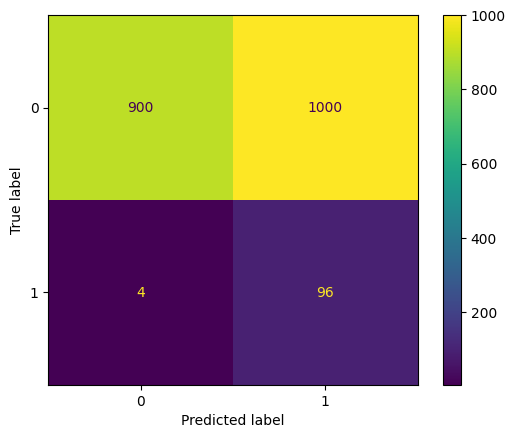

{'f1': 0.16, 'accuracy': 0.5, 'balanced_accuracy': 0.72, 'recall': 0.96, 'precision': 0.09, 'specificity': 0.47}


{'f1': 0.16,
 'accuracy': 0.5,
 'balanced_accuracy': 0.72,
 'recall': 0.96,
 'precision': 0.09,
 'specificity': 0.47}

In [ ]:
# Test
model = GradSQBC()
model.fit(X_train_heart, y_train_heart, theta=0.3, verbose=True)
pred =  model.predict(X_test_heart)
evaluate(y_test_heart, pred)

## Pipeline

#### **Time comparison**

In [ ]:
def benchmark(model, X_train, y_train, X_test, y_test):
    
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start
    
    return train_time


models = {
    "XGBoost": xgb.XGBClassifier(),
    "LightGBM": lgb.LGBMClassifier(),
    "CatBoost": CatBoostClassifier(),
    "SQBC": SQBC(),
    "XGBSQBC": XGBSQBC(),
    "GradSQBC": GradSQBC()
}


results = {}
for name, model in models.items():
    print(f"===== {name} =====")
    results[name] = benchmark(model, X_train_01, y_train_01, X_test_01, y_test_01)

===== XGBoost =====
===== LightGBM =====
===== CatBoost =====
Learning rate set to 0.025035
0:	learn: 0.6590623	total: 36.3ms	remaining: 36.3s
1:	learn: 0.6366887	total: 58.3ms	remaining: 29.1s
2:	learn: 0.6109489	total: 249ms	remaining: 1m 22s
3:	learn: 0.5891064	total: 284ms	remaining: 1m 10s
4:	learn: 0.5636299	total: 308ms	remaining: 1m 1s
5:	learn: 0.5420013	total: 338ms	remaining: 56s
6:	learn: 0.5190089	total: 350ms	remaining: 49.6s
7:	learn: 0.5014034	total: 362ms	remaining: 44.9s
8:	learn: 0.4816118	total: 384ms	remaining: 42.2s
9:	learn: 0.4648567	total: 417ms	remaining: 41.3s
10:	learn: 0.4488001	total: 425ms	remaining: 38.2s
11:	learn: 0.4358364	total: 442ms	remaining: 36.4s
12:	learn: 0.4246972	total: 457ms	remaining: 34.7s
13:	learn: 0.4120093	total: 471ms	remaining: 33.2s
14:	learn: 0.3969409	total: 480ms	remaining: 31.5s
15:	learn: 0.3866784	total: 490ms	remaining: 30.1s
16:	learn: 0.3759188	total: 501ms	remaining: 29s
17:	learn: 0.3642647	total: 509ms	remaining: 27.8s


In [399]:
results

{'XGBoost': 2.4998960494995117,
 'LightGBM': 1.108022928237915,
 'CatBoost': 12.022714138031006,
 'SQBC': 8.409363269805908,
 'XGBSQBC': 0.874443769454956,
 'GradSQBC': 9.137168884277344}

#### **Prediction results**

In [ ]:
def combine_results(grid_metrics_dicts, model_names, opt_metric='pr_auc'):
    """
    Combine metrics reuslts into a single summary DataFrame.
    """

    combined_df = pd.DataFrame()

    for i, dict in enumerate(grid_metrics_dicts):
        grid_df = pd.DataFrame([grid_metrics_dicts[i]], index=[f"{model_names[i]}"])
        combined_df = pd.concat([combined_df, grid_df], axis=0)

    
    combined_df = combined_df.sort_values(by=opt_metric, ascending=False)

    # Display with style
    format_dict = {col: "{:.2f}" for col in combined_df.select_dtypes(include='number').columns}
    styled_df = (
        combined_df
        .style
        .format(format_dict)
        .set_table_styles([
            {'selector': f'th.col{i}', 'props': [('color', 'blue'), ('font-weight', 'bold')]} 
            for i, col in enumerate(combined_df.columns) if col == opt_metric
        ])
    )
    display(styled_df)

    return 

In [ ]:
def run_all_experiments(datasets, model_trainers, 
                        model_trainers_names, 
                        model_names, opt_metric="pr_auc"):
    """
    Run specified models on specified datasets and return tables of results. 
    """

    for dataset_name, (X_train, y_train, X_test, y_test) in datasets.items():
        print(f"===== Dataset: {dataset_name} =====\n")

        metrics_list = []

        for i, trainer in enumerate(model_trainers):
            name = model_trainers_names[i]
            print(f"Model: {name}")

            metrics = trainer(X_train, y_train, X_test, y_test, opt_metric=opt_metric)
            if name[:8]=="Pipeline": 
                metrics_list += metrics
            else:
                metrics_list.append(metrics)

        combine_results(metrics_list, model_names, opt_metric=opt_metric)

    return

In [ ]:
datasets = {
    "Synthetic: p=50%, n=10000": (X_train_05, y_train_05, X_test_05, y_test_05),
    "Synthetic: p=10%, n=10000": (X_train_01, y_train_01, X_test_01, y_test_01),
    "Synthetic: p=5%, n=10000": (X_train_005, y_train_005, X_test_005, y_test_005),
    "Synthetic: p=1%, n=10000": (X_train_001, y_train_001, X_test_001, y_test_001),
    "Synthetic: p=0.1%, n=10000": (X_train_0001, y_train_0001, X_test_0001, y_test_0001),
    "Sheart: p=54.5%, n=303": (X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart),
    "Churn: p=20.4%, n=9799": (X_train_churn, y_train_churn, X_test_churn, y_test_churn),
    "Heart: p=5%, n=10000": (X_train_heart, y_train_heart, X_test_heart, y_test_heart),
}

model_names=[
    "XGBoost", "LightGBM", "CatBoost", "RF", "Log",
    "SQBC",  "SQBC_gs", 
    "XGB_SQBC", "XGB_SQBC_gs", 
    "Grad M1", "Grad M2"
]

model_trainers = [
    partial(pipeline_sota, verbose=False), 
    partial(train_eval_sqbc, verbose=False),
    partial(grid_search_tau_interpolated, verbose=False), 
    partial(train_eval_xgb_sqbc),
    partial(grid_search_tau_interpolated, verbose=False, model_type="XGB"),
    partial(train_eval_grad_sqbc, method=1), 
    partial(train_eval_grad_sqbc, method=2)
]

model_trainers_names=[
    "Pipeline SOTA", 
    "SQBC", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC method 1", "Grad_SQBC method 2"
]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Log,0.99,0.93,0.99,0.94,0.92,0.94,0.94,0.50,nan
Grad M2,0.99,0.94,0.99,0.94,0.92,0.95,0.95,0.00,0.50
CatBoost,0.98,0.91,0.98,0.91,0.91,0.92,0.92,0.50,nan
XGBoost,0.97,0.89,0.97,0.89,0.89,0.90,0.90,0.50,nan
LightGBM,0.97,0.89,0.96,0.89,0.89,0.89,0.89,0.50,nan
SQBC,0.96,0.88,0.96,0.88,0.88,0.88,0.88,0.00,0.50
SQBC_gs,0.96,0.86,0.96,0.88,0.79,0.95,0.96,0.00,0.46
Grad M1,0.96,0.88,0.96,0.88,0.88,0.88,0.88,0.00,0.50
RF,0.95,0.87,0.95,0.87,0.87,0.87,0.87,0.50,nan
XGB_SQBC,0.95,0.87,0.95,0.87,0.86,0.88,0.88,0.50,0.50


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Log,0.96,0.91,1.00,0.98,0.90,0.91,0.99,0.50,nan
Grad M2,0.96,0.89,1.00,0.98,0.90,0.88,0.99,0.00,0.52
CatBoost,0.92,0.78,0.99,0.96,0.68,0.93,0.99,0.50,nan
XGBoost,0.90,0.76,0.99,0.96,0.66,0.89,0.99,0.50,nan
LightGBM,0.90,0.72,0.99,0.96,0.58,0.96,1.00,0.50,nan
XGB_SQBC,0.85,0.62,0.98,0.94,0.46,0.93,1.00,0.50,0.50
XGB_SQBC_gs,0.85,0.65,0.98,0.95,0.50,0.94,1.00,0.50,0.52
RF,0.82,0.36,0.97,0.92,0.22,0.98,1.00,0.50,nan
SQBC_gs,0.82,0.74,0.98,0.95,0.76,0.72,0.97,0.00,0.57
Grad M1,0.82,0.64,0.97,0.94,0.51,0.86,0.99,0.00,0.53


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


...

/Users/swendy/opt/miniconda3/envs/summer_proj/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
XGBoost,0.23,0.09,0.52,0.77,0.06,0.26,0.96,0.50,nan
Log,0.22,0.00,0.52,0.80,0.00,0.00,1.00,0.50,nan
LightGBM,0.21,0.01,0.51,0.79,0.00,0.33,1.00,0.50,nan
CatBoost,0.21,0.00,0.50,0.80,0.00,0.00,1.00,0.50,nan
SQBC,0.21,0.00,0.52,0.80,0.00,0.00,1.00,0.00,0.50
XGB_SQBC_gs,0.21,0.34,0.51,0.21,1.00,0.20,0.00,0.50,0.81
Grad M1,0.21,0.00,0.52,0.80,0.00,0.00,1.00,0.00,0.48
Grad M2,0.21,0.00,0.51,0.80,0.00,0.00,1.00,0.00,0.46
SQBC_gs,0.20,0.34,0.50,0.20,1.00,0.20,0.00,0.00,0.81
RF,0.19,0.00,0.47,0.80,0.00,0.00,1.00,0.50,nan


===== Dataset: Heart: p=5%, n=10000 =====

Model: Pipeline SOTA
Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Log,0.22,0.09,0.83,0.95,0.05,0.36,1.00,0.50,nan
SQBC_gs,0.20,0.02,0.82,0.95,0.01,0.25,1.00,0.00,0.52
Grad M1,0.20,0.02,0.82,0.95,0.01,0.25,1.00,0.00,0.52
Grad M2,0.20,0.04,0.82,0.95,0.02,0.50,1.00,0.00,0.51
SQBC,0.19,0.00,0.82,0.95,0.00,0.00,1.00,0.00,0.50
XGB_SQBC,0.19,0.04,0.82,0.95,0.02,0.25,1.00,0.50,0.50
LightGBM,0.17,0.08,0.82,0.94,0.05,0.25,0.99,0.50,nan
XGB_SQBC_gs,0.17,0.10,0.80,0.05,1.00,0.05,0.00,0.50,0.93
CatBoost,0.16,0.08,0.80,0.94,0.05,0.25,0.99,0.50,nan
XGBoost,0.15,0.09,0.80,0.94,0.06,0.17,0.98,0.50,nan


In [329]:
datasets = {
    "Fraud: p=0.1%, n=80000": (X_train_fraud, y_train_fraud, X_test_fraud, y_test_fraud)
}

model_names=[
    "XGBoost", "LightGBM", "CatBoost", "RF", "Log",
    "SQBC", "SQBC_gs", 
    "XGB_SQBC", "XGB_SQBC_gs", 
    "Grad M1"
]

model_trainers = [
    partial(pipeline_sota, verbose=False),  
    partial(train_eval_sqbc, verbose=False),
    partial(grid_search_tau_interpolated, verbose=False), 
    partial(train_eval_xgb_sqbc),
    partial(grid_search_tau_interpolated, verbose=False, model_type="XGB"),
    partial(train_eval_grad_sqbc, method=1)
]

model_trainers_names=[
    "Pipeline SOTA", 
    "SQBC", "SQBC_grid_search", 
    "XGB_SQBC_loss", "XGB_SQBC_loss_grid_search", 
    "Grad_SQBC method 1"
]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Fraud: p=0.1%, n=80000 =====

Model: Pipeline SOTA


Model: SQBC
Model: SQBC_grid_search
Model: XGB_SQBC_loss
Model: XGB_SQBC_loss_grid_search
Model: Grad_SQBC method 1


,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
RF,0.59,0.62,0.89,1.00,0.56,0.71,1.00,0.50,nan
CatBoost,0.56,0.43,1.00,1.00,0.33,0.60,1.00,0.50,nan
XGB_SQBC,0.51,0.67,1.00,1.00,0.56,0.83,1.00,0.50,0.50
XGBoost,0.44,0.43,1.00,1.00,0.33,0.60,1.00,0.50,nan
XGB_SQBC_gs,0.43,0.00,0.99,0.00,1.00,0.00,0.00,0.50,0.81
SQBC_gs,0.34,0.00,0.99,0.00,1.00,0.00,0.00,0.00,0.81
SQBC,0.31,0.33,0.83,1.00,0.22,0.67,1.00,0.00,0.50
Grad M1,0.30,0.33,0.83,1.00,0.22,0.67,1.00,0.00,0.53
Log,0.07,0.00,0.83,1.00,0.00,0.00,1.00,0.50,nan
LightGBM,0.00,0.03,0.32,1.00,0.11,0.02,1.00,0.50,nan


In [ ]:
datasets = {
    "Synthetic: p=50%, n=10000": (X_train_05, y_train_05, X_test_05, y_test_05),
    "Synthetic: p=10%, n=10000": (X_train_01, y_train_01, X_test_01, y_test_01),
    "Synthetic: p=5%, n=10000": (X_train_005, y_train_005, X_test_005, y_test_005),
    "Synthetic: p=1%, n=10000": (X_train_001, y_train_001, X_test_001, y_test_001),
    "Synthetic: p=0.1%, n=10000": (X_train_0001, y_train_0001, X_test_0001, y_test_0001),
    "Sheart: p=54.5%, n=303": (X_train_sheart, y_train_sheart, X_test_sheart, y_test_sheart),
    "Churn: p=20.4%, n=9799": (X_train_churn, y_train_churn, X_test_churn, y_test_churn),
    "Heart: p=5%, n=10000": (X_train_heart, y_train_heart, X_test_heart, y_test_heart),
}

model_names=["Grad M1", "Grad M2"]

model_trainers = [
    partial(train_eval_grad_sqbc, base_learner="OLS", method=1), 
    partial(train_eval_grad_sqbc, method=2)
]

model_trainers_names=[ 
    "Grad_SQBC method 1", "Grad_SQBC method 2"
]

run_all_experiments(datasets, model_trainers, model_trainers_names, model_names)

===== Dataset: Synthetic: p=50%, n=10000 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.99,0.94,0.99,0.94,0.92,0.95,0.95,0.00,0.50
Grad M2,0.99,0.94,0.99,0.94,0.92,0.95,0.95,0.00,0.50


===== Dataset: Synthetic: p=10%, n=10000 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.96,0.89,1.00,0.98,0.90,0.88,0.99,0.00,0.52
Grad M2,0.96,0.89,1.00,0.98,0.90,0.88,0.99,0.00,0.52


===== Dataset: Synthetic: p=5%, n=10000 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


...

,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.90,0.91,0.90,0.90,0.94,0.89,0.86,0.00,0.50
Grad M2,0.90,0.90,0.90,0.89,0.94,0.86,0.82,0.00,0.50


===== Dataset: Churn: p=20.4%, n=9799 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.21,0.00,0.51,0.80,0.00,0.00,1.00,0.00,0.48
Grad M2,0.21,0.00,0.51,0.80,0.00,0.00,1.00,0.00,0.46


===== Dataset: Heart: p=5%, n=10000 =====

Model: Grad_SQBC method 1
Model: Grad_SQBC method 2


,pr_auc,f1,roc_auc,accuracy,recall,precision,specificity,Threshold,Level_tau
Grad M1,0.20,0.04,0.82,0.95,0.02,0.33,1.00,0.00,0.52
Grad M2,0.20,0.04,0.82,0.95,0.02,0.50,1.00,0.00,0.51


#### **Plot of results**

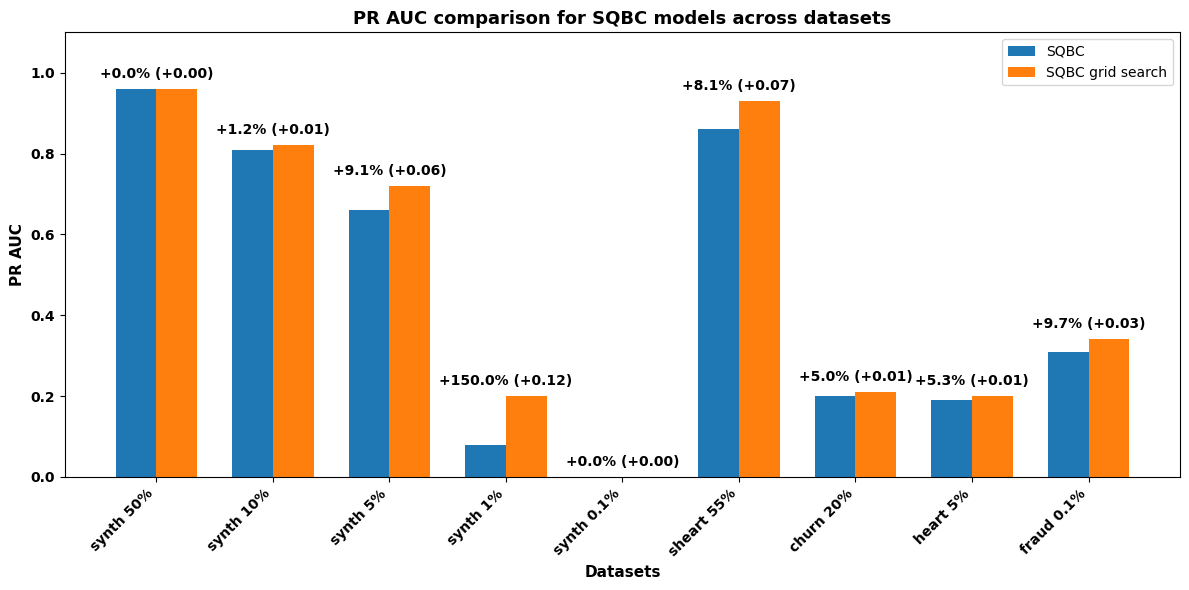

In [ ]:
datasets = [
    "synth 50%", "synth 10%", "synth 5%", "synth 1%", "synth 0.1%",
    "sheart 55%", "churn 20%", "heart 5%", "fraud 0.1%"
]

models = ["SQBC", "SQBC grid search"]


pr_auc_values = np.array([
    [0.96, 0.96],   
    [0.81, 0.82],   
    [0.66, 0.72],  
    [0.08, 0.2],
    [0, 0],   
    [0.86, 0.93],   
    [0.20, 0.21],   
    [0.19, 0.20],  
    [0.31, 0.34]    
])

x = np.arange(len(datasets))
width = 0.35  

fig, ax = plt.subplots(figsize=(12, 6))

bars = []
for i, model in enumerate(models):
    bar = ax.bar(x + i*width, pr_auc_values[:, i], width, label=model)
    bars.append(bar)


for j in range(len(datasets)):
    val1 = pr_auc_values[j, 0]
    val2 = pr_auc_values[j, 1]
    diff = val2 - val1
    if val1 == val2:
        diff_pct = 0
    else:
        diff_pct = diff / min(val1, val2) * 100
    y_pos = max(val1, val2) + 0.02  
    ax.text(
        x[j] + width/2, y_pos, f'{diff_pct:+.1f}% ({diff:+.2f})', 
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_ylabel("PR AUC", fontweight="bold", fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_xlabel("Datasets", fontweight="bold", fontsize=11)
ax.set_xticks(x + width / 2)
ax.set_title("PR AUC comparison for SQBC models across datasets", 
            fontweight="bold", fontsize=13)
ax.set_xticklabels(datasets, rotation=45, ha="right", 
            fontweight="bold")

for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

plt.legend()
plt.tight_layout()
plt.savefig("Figures/results_sqbc.pdf", dpi=600, format="pdf")
plt.show()

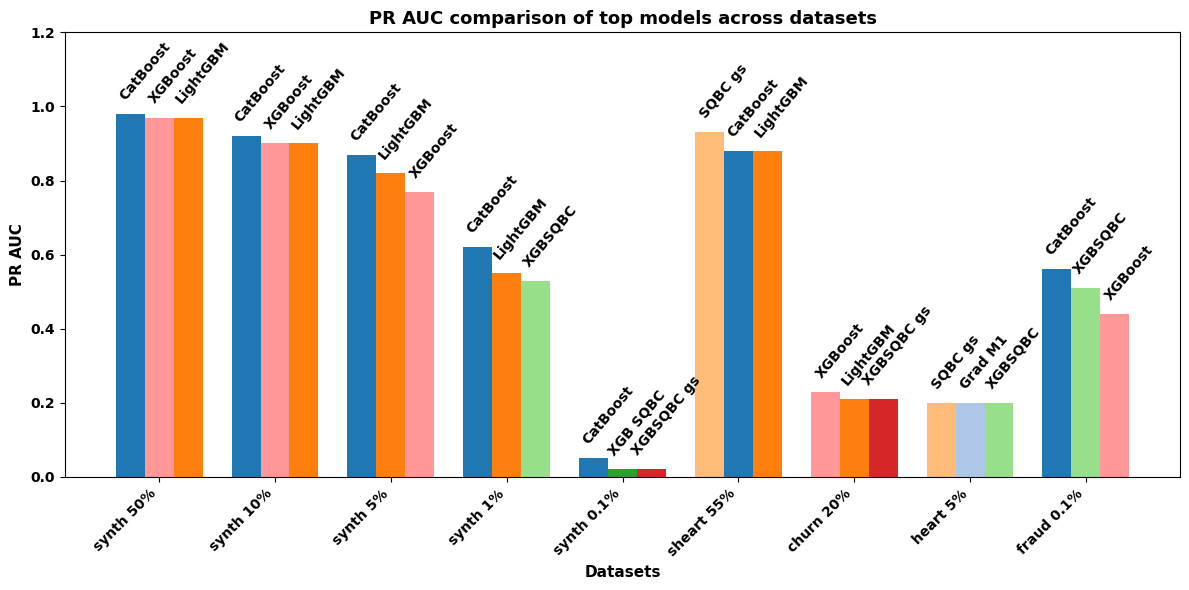

In [ ]:
datasets = [
    "synth 50%", "synth 10%", "synth 5%", "synth 1%", "synth 0.1%",
    "sheart 55%", "churn 20%", "heart 5%", "fraud 0.1%"
]

top_models = [
    ["CatBoost", "XGBoost", "LightGBM"],
    ["CatBoost", "XGBoost", "LightGBM"],
    ["CatBoost", "LightGBM", "XGBoost"],
    ["CatBoost", "LightGBM", "XGBSQBC"],
    ["CatBoost", "XGB SQBC", "XGBSQBC gs"],
    ["SQBC gs", "CatBoost", "LightGBM"],
    ["XGBoost", "LightGBM", "XGBSQBC gs"],
    ["SQBC gs", "Grad M1", "XGBSQBC"],
    ["CatBoost", "XGBSQBC", "XGBoost"]
]

pr_auc_values = np.array([
    [0.98, 0.97, 0.97],   
    [0.92, 0.90, 0.90],   
    [0.87, 0.82, 0.77],  
    [0.62, 0.55, 0.53],
    [0.05, 0.02, 0.02],   
    [0.93, 0.88, 0.88],   
    [0.23, 0.21, 0.21],   
    [0.20, 0.20, 0.20],  
    [0.56, 0.51, 0.44]    
])

 
unique_models = sorted(set([m for trio in top_models for m in trio]))
color_map = {model: plt.cm.tab20(i) for i, model in enumerate(unique_models)}

x = np.arange(len(datasets))
width = 0.25  

fig, ax = plt.subplots(figsize=(12, 6))

for i in range(3):  
    model_names = [m[i] for m in top_models]
    colors = [color_map[m] for m in model_names]
    bars = ax.bar(x + i*width, pr_auc_values[:, i], width, color=colors)
    
    for bar, label in zip(bars, model_names):
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width(), height + 0.03, label,
            ha='center', va='bottom', rotation=50,
            fontweight='bold'
        )

ax.set_ylabel("PR AUC", fontweight='bold', fontsize=11)
ax.set_xlabel("Datasets", fontweight='bold', fontsize=11)
ax.set_title("PR AUC comparison of top models across datasets", 
            fontweight='bold', fontsize=13)
ax.set_xticks(x + width)
ax.set_xticklabels(datasets, rotation=45, ha="right", fontweight='bold')
ax.set_ylim(0, 1.2)

if ax.get_legend():
    ax.get_legend().remove()
for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')

plt.tight_layout()
plt.savefig("Figures/results_top.pdf", dpi=600, format="pdf")
plt.show()

## *Test*
**Unused section**

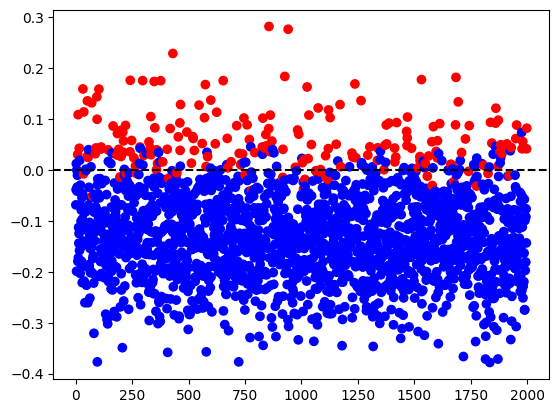

In [552]:
model_sqbc = GradSQBC()
model_sqbc.fit(X_train_01, y_train_01)
y_pred_sqbc = model_sqbc.predict_quantile(X_test_01)

plt.scatter(range(len(y_pred_sqbc)), y_pred_sqbc, c=y_test_01, cmap='bwr')  
plt.axhline(color='black', linestyle='--')

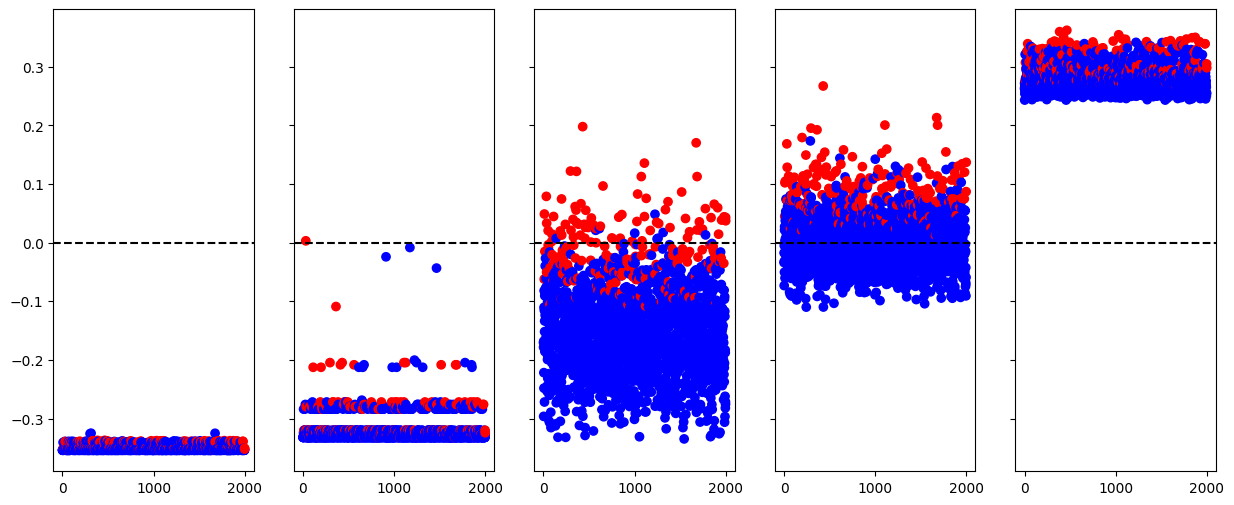

In [89]:
fig, axs = plt.subplots(1, 5, figsize=(15, 6),sharey=True)

for i, tau in enumerate([0.1, 0.3, 0.5, 0.7, 0.9]): 
 
    model_sqbc = SQBC(tau=tau)
    model_sqbc.fit(X_train_01, y_train_01)
    y_pred_sqbc = model_sqbc.predict_quantile(X_test_01)

    axs[i].scatter(range(len(y_pred_sqbc)), y_pred_sqbc, c=y_test_01, cmap='bwr')  
    axs[i].axhline(color='black', linestyle='--')


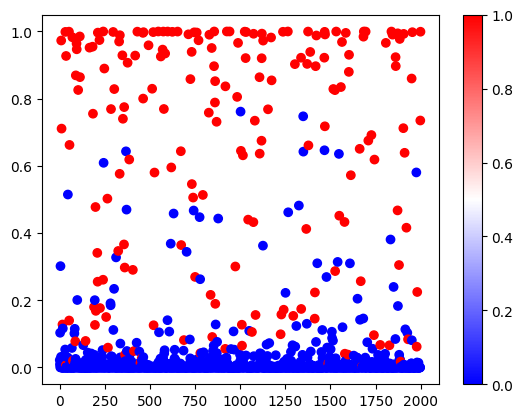

In [557]:
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train_01, y_train_01)
y_pred_xgb = model_xgb.predict_proba(X_test_01)[:,1]

plt.scatter(range(len(y_pred_xgb)), y_pred_xgb, c=y_test_01, cmap='bwr')  
plt.colorbar()  
plt.show()

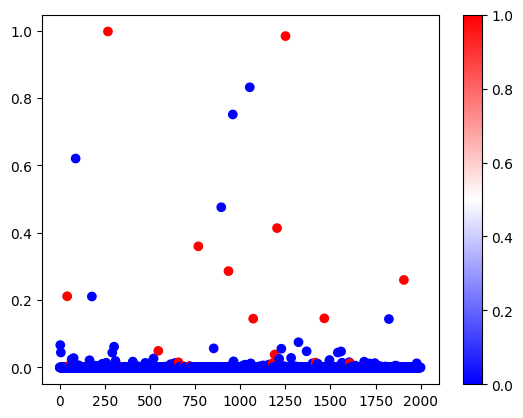

In [92]:
model_xgb = xgb.XGBClassifier()
model_xgb.fit(X_train_001, y_train_001)
y_pred_xgb = model_xgb.predict_proba(X_test_001)[:,1]

plt.scatter(range(len(y_pred_xgb)), y_pred_xgb, c=y_test_001, cmap='bwr')  
plt.colorbar()  
plt.show()

## Plots

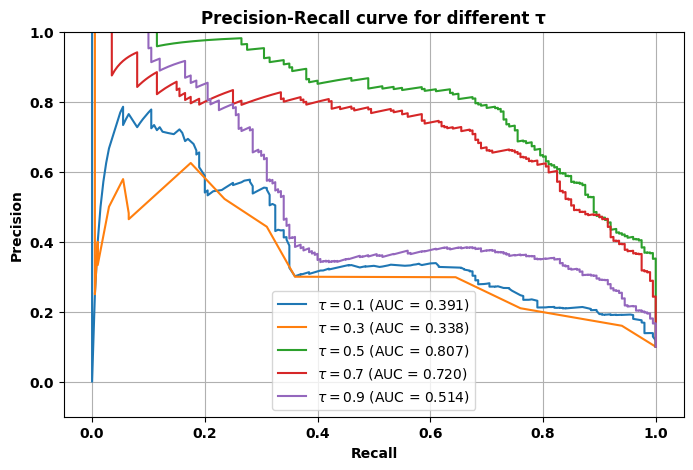

In [ ]:
# Precision-Recall curves
 
tau_range = [0.1, 0.3, 0.5, 0.7, 0.9]

plt.figure(figsize=(8,5))

for tau in tau_range:
    sqbc = SQBC(tau=tau)
    sqbc.fit(X_train_01, y_train_01)
    
    scores = sqbc.predict_quantile(X_test_01)
    
    precision, recall, thresholds = precision_recall_curve(y_test_01, scores)
    pr_auc = auc(recall, precision)
    
    plt.plot(recall, precision, label=fr'$\tau={tau}$ (AUC = {pr_auc:.3f})')

plt.xlabel("Recall", fontweight="bold")
plt.ylabel("Precision", fontweight="bold")
plt.title("Precision-Recall curve for different τ", fontweight="bold")
ax = plt.gca()
ax.set_ylim(-0.1, 1)

for tick in ax.get_yticklabels():
    tick.set_fontweight('bold')
for tick in ax.get_xticklabels():
    tick.set_fontweight('bold')

plt.legend()
plt.grid(True)
plt.savefig("Figures/pr_curve.pdf", dpi=600, format="pdf")
plt.show()


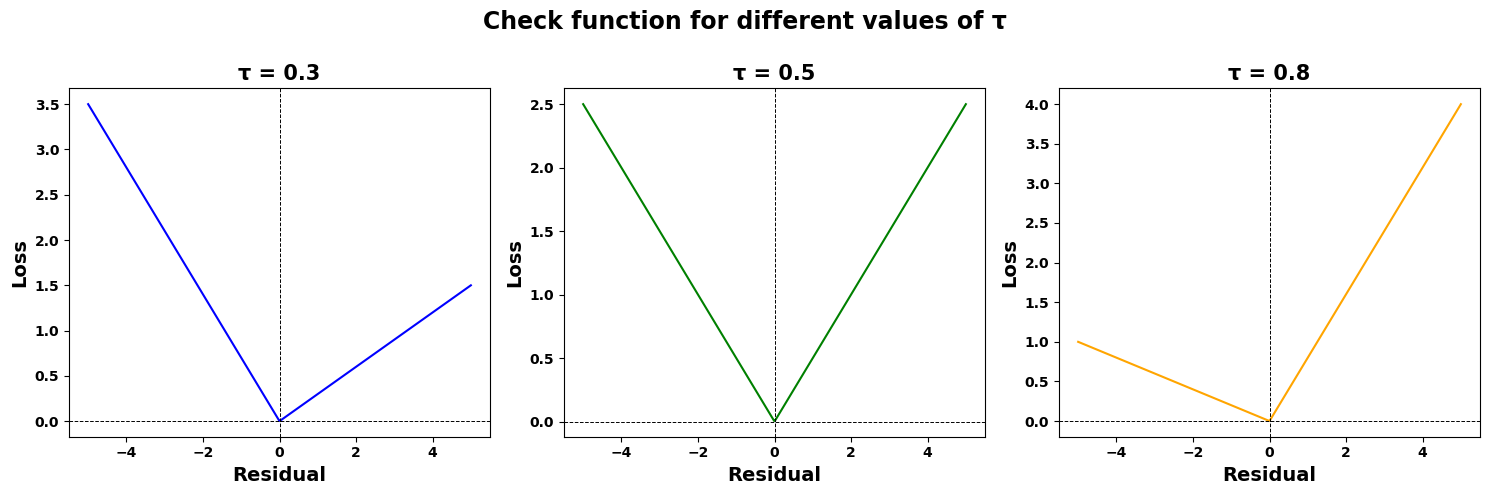

In [ ]:
# Check functions

def check_function(u, tau):
    return np.where(u >= 0, tau*u, (tau - 1)*u)

u = np.linspace(-5, 5, 500)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
taus = [0.3, 0.5, 0.8]
colors = ['blue', 'green', 'orange']

for i, tau in enumerate(taus):

    loss = check_function(u, tau)

    ax[i].plot(u, loss, label=f'τ = {tau}', color=colors[i])
    ax[i].axvline(0, color='black', linewidth=0.7, linestyle='--')
    ax[i].axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax[i].set_title(f"τ = {tau}", fontsize=15, fontweight='bold')
    ax[i].set_xlabel("Residual", fontsize=14, fontweight='bold')
    ax[i].set_ylabel("Loss", fontsize=14, fontweight='bold')

    for tick in ax[i].get_yticklabels():
        tick.set_fontweight('bold')
    for tick in ax[i].get_xticklabels():
        tick.set_fontweight('bold')


plt.suptitle("Check function for different values of τ", 
            fontsize=17, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("Figures/check_function.pdf", dpi=600, format="pdf")
plt.show()

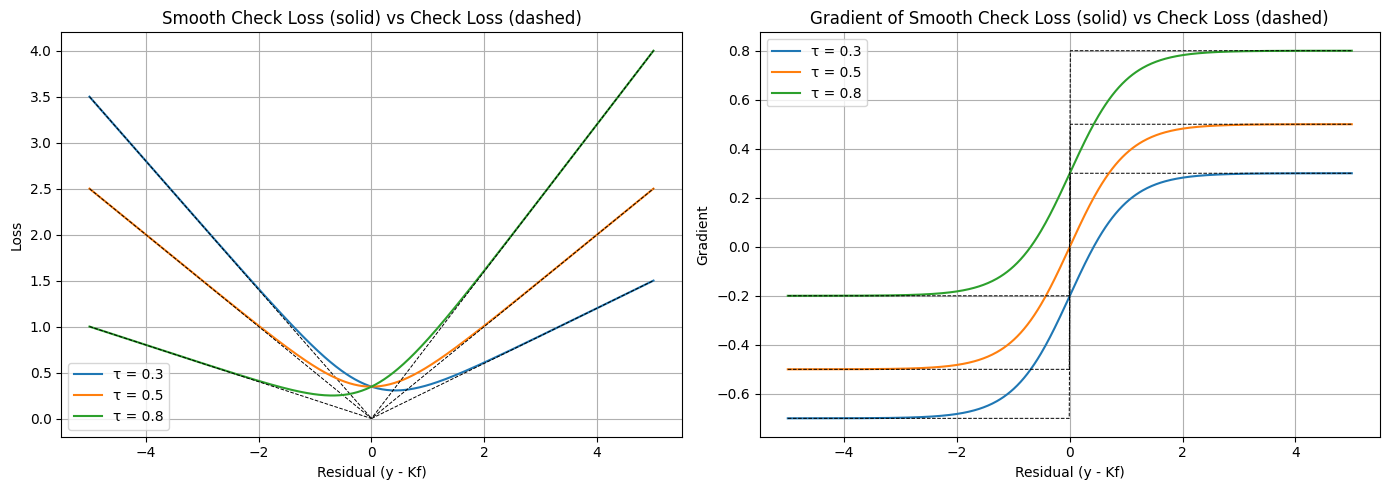

In [451]:
# MSmooth VS non-smooth check functions

res = np.linspace(-5, 5, 500)
alpha = 0.5
taus = [0.3, 0.5, 0.8]


def smooth_check(u, tau, alpha):
    return tau * u + alpha * np.log1p(np.exp(-u / alpha))

def grad_smooth_check(u, tau, alpha):
    return - (1 / (1 + np.exp(u / alpha)) - tau)

def check_loss(u, tau):
    return np.where(u >= 0, tau * u, (tau - 1) * u)

def grad_check_loss(u, tau):
    return np.where(u >= 0, tau, tau - 1)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for tau in taus:
   
    axes[0].plot(res, smooth_check(res, tau, alpha), label=f'τ = {tau}')
    axes[1].plot(res, grad_smooth_check(res, tau, alpha), label=f'τ = {tau}')
    axes[0].plot(res, check_loss(res, tau), linestyle='dashed', color='black', linewidth=0.7)
    axes[1].plot(res, grad_check_loss(res, tau), linestyle='dashed', color='black',linewidth=0.7)


axes[0].set_title("Smooth Check Loss (solid) vs Check Loss (dashed)")
axes[0].set_xlabel("Residual (y - Kf)")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].set_title("Gradient of Smooth Check Loss (solid) vs Check Loss (dashed)")
axes[1].set_xlabel("Residual (y - Kf)")
axes[1].set_ylabel("Gradient")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()


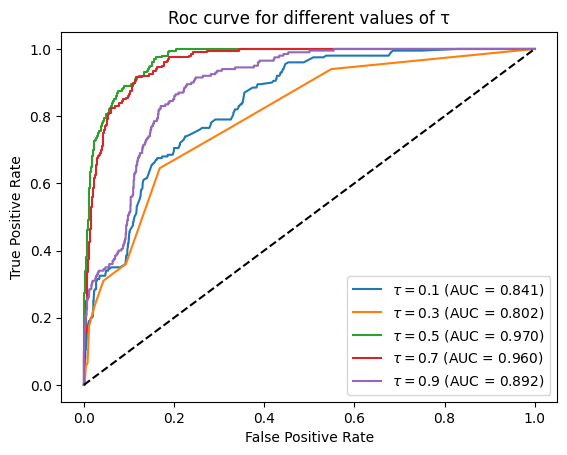

In [ ]:
# ROC curves

tau_range = [0.1, 0.3, 0.5, 0.7, 0.9]

for tau in tau_range: 

    sqbc = SQBC(tau=tau)
    sqbc.fit(X_train_01, y_train_01)

    scores = sqbc.predict_quantile(X_test_01)

    fpr, tpr, thresholds = roc_curve(y_test_01, scores)
    auc = roc_auc_score(y_test_01, scores)

    plt.plot(fpr, tpr, label=fr'$\tau={tau}$ (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Roc curve for different values of τ")
plt.legend()
plt.show()


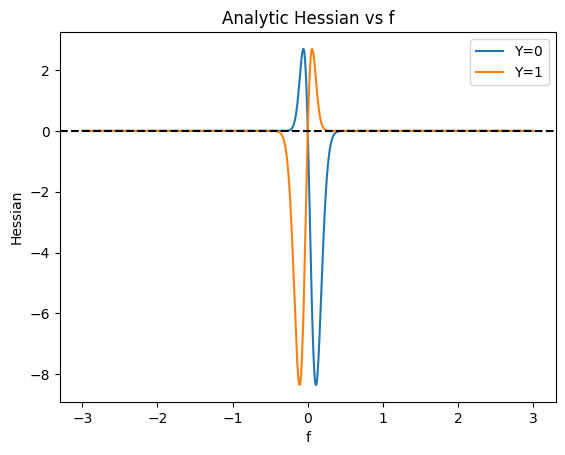

In [ ]:
# Hessian 

h = 0.1
alpha = 0.5
tau = 0.5

def K(z): return norm.cdf(z)
def phi(z): return norm.pdf(z)

def hessian(f, Y):
    z = f / h
    Kfz = K(z)
    phiz = phi(z)
    L = np.exp((Y - Kfz) / alpha)  # L>0
    term1 = (f / h**3) * phiz * (tau - 1 / (1 + L))
    term2 = (1 / alpha) * ((f / h) * phiz)**2 * (L / (1 + L)**2)
    return term1 + term2

f_values = np.linspace(-3, 3, 1000)
for Y in (0, 1):
    hess_vals = [hessian(f, Y) for f in f_values]
    plt.plot(f_values, hess_vals, label=f'Y={Y}')
    
plt.axhline(0, color='k', linestyle='--')
plt.xlabel('f')
plt.ylabel('Hessian')
plt.legend()
plt.title('Analytic Hessian vs f')
plt.show()
